<a href="https://colab.research.google.com/github/JoGabTasca/NLP/blob/main/TAREFA_Analise_Sentimento_Olist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Análise de Sentimentos - Olist dataset**

Autor(a): Camilla Fonseca (adaptado)

Vamos treinar um modelo de análise de sentimentos utilizando o dataset [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/olistbr/brazilian-ecommerce), e comparar as técnicas clássicas de *feature extraction*: Bag of Words e TF-IDF.

A análise de sentimentos é uma tarefa de NLP que visa classificar os sentimentos de um texto dividindo-os, por exemplo, em positivo, negativo ou neutro, ou feliz, triste, nervoso ou neutro, ou várias outras formas, dependendo do seu problema.

Isso tem aplicações interessantes, como por exemplo, saber se o público está gostando ou não de determinado produto. Podemos treinar um modelo para esta tarefa extraindo comentários sobre o produto em um e-commerce.

**Sobre o dataset**

O Brazilian E-Commerce Public Dataset by Olist possui diversos dados sobre compras feitas no site Olist. Se você der uma conferida no link, verá que há vários arquivos, porém aqui estaremos usando apenas o `olist_order_reviews_dataset.csv`, que contém as análises feitas pelos usuários dessas compras.

A título de curiosidade, é interessante observar que os dados foram anonimizados e por isso no texto aparecem nomes de casas de Game of Thrones no lugar do nome das lojas.

# Pré-processamento


Importando as bibliotecas.

In [ ]:
import pandas as pd
import re
import nltk
import spacy
import matplotlib.pyplot as plt
import seaborn as sns

Carregando e organizando o dataset.

In [ ]:
# Carregando o dataset
data = pd.read_csv("https://github.com/cassiusf/datasets/raw/refs/heads/main/nlp/olist_order_reviews_dataset.csv")

In [ ]:
data.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


Como nosso foco é a análise de sentimentos, não precisamos das colunas `order_id`, `review_creation_date` e `review_answer_timestamp`.

In [ ]:
data.drop(['order_id', 'review_creation_date', 'review_answer_timestamp'], axis=1, inplace=True)

Verificando a estrutura final do dataframe.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   review_id               99224 non-null  object
 1   review_score            99224 non-null  int64 
 2   review_comment_title    11568 non-null  object
 3   review_comment_message  40977 non-null  object
dtypes: int64(1), object(3)
memory usage: 3.0+ MB


Temos pouco menos de 100.000 linhas, todas possuindo um escore de avaliação, mas nem todos possuem análise escrita. Vamos então verificar se há dados duplicados (com base no id) e removê-los.

In [ ]:
duplicados = round(sum(data.duplicated("review_id"))/len(data)*100, 2)
print(f"Reviews com id duplicado: {duplicados}%.")

Reviews com id duplicado: 0.82%.


In [ ]:
data[data.duplicated("review_id", keep =  False)].sort_values(by = "review_id")

,review_id,review_score,review_comment_title,review_comment_message
46678,00130cbe1f9d422698c812ed8ded1919,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid..."
29841,00130cbe1f9d422698c812ed8ded1919,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid..."
90677,0115633a9c298b6a98bcbe4eee75345f,5,NaN,NaN
63193,0115633a9c298b6a98bcbe4eee75345f,5,NaN,NaN
92876,0174caf0ee5964646040cd94e15ac95e,1,NaN,Produto entregue dentro de embalagem do fornec...
...,...,...,...,...
31120,fe5c833752953fed3209646f1f63b53c,1,NaN,"Comprei dois produtos e ambos, mesmo enviados ..."
7870,ff2fc9e68f8aabfbe18d710b83aabd30,2,NaN,NaN
82521,ff2fc9e68f8aabfbe18d710b83aabd30,2,NaN,NaN
73951,ffb8cff872a625632ac983eb1f88843c,3,NaN,NaN


In [ ]:
data.drop_duplicates("review_id", inplace=True)

Como estamos interessados justamente no texto, vamos juntar as colunas `review_comment_title` e `review_comment_message` em uma só e tirar entradas que não possuem texto.

In [ ]:
# Para não ter problemas com nulos na concatenação
data.fillna('', inplace=True)

In [ ]:
# Concatenando as duas colunas
data['review'] = data['review_comment_title'] + ' ' + data['review_comment_message']

In [ ]:
# Removendo entradas sem texto
data = data[data['review'] != ' ']

Após esses ajustes, ficamos com pouco mais de 42.000 linhas de dados.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 42389 entries, 3 to 99223
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   review_id               42389 non-null  object
 1   review_score            42389 non-null  int64 
 2   review_comment_title    42389 non-null  object
 3   review_comment_message  42389 non-null  object
 4   review                  42389 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.9+ MB


In [ ]:
data.head()

,review_id,review_score,review_comment_title,review_comment_message,review
3,e64fb393e7b32834bb789ff8bb30750e,5,,Recebi bem antes do prazo estipulado.,Recebi bem antes do prazo estipulado.
4,f7c4243c7fe1938f181bec41a392bdeb,5,,Parabéns lojas lannister adorei comprar pela I...,Parabéns lojas lannister adorei comprar pela ...
9,8670d52e15e00043ae7de4c01cc2fe06,4,recomendo,aparelho eficiente. no site a marca do aparelh...,recomendo aparelho eficiente. no site a marca ...
12,4b49719c8a200003f700d3d986ea1a19,4,,"Mas um pouco ,travando...pelo valor ta Boa.\r\n","Mas um pouco ,travando...pelo valor ta Boa.\r\n"
15,3948b09f7c818e2d86c9a546758b2335,5,Super recomendo,"Vendedor confiável, produto ok e entrega antes...","Super recomendo Vendedor confiável, produto ok..."


### Review scores

In [ ]:
data['review_score'].value_counts()

,count
review_score,
5,21672
1,8723
4,6241
3,3615
2,2138


Na coluna `review_score`, há cinco possibilidades de notas diferentes (de 1, pior, até 5, melhor), porém, para facilitar nossa tarefa, vamos transformar nosso problema em binário, classificando as avaliações apenas como positiva ou negativa.

Se  nota for menor ou igual a 3, consideraremos negativa (0) e caso contrário, positiva (1).

Esses serão os rótulos (variável alvo) que usaremos para treinar o modelo e vamos armazená-los em uma nova coluna:

In [ ]:
labels = []

for score in data['review_score']:
  if score > 3:
    labels.append(1)
  else:
    labels.append(0)

data['label'] = labels

In [ ]:
data.head(10)

,review_id,review_score,review_comment_title,review_comment_message,review,label
3,e64fb393e7b32834bb789ff8bb30750e,5,,Recebi bem antes do prazo estipulado.,Recebi bem antes do prazo estipulado.,1
4,f7c4243c7fe1938f181bec41a392bdeb,5,,Parabéns lojas lannister adorei comprar pela I...,Parabéns lojas lannister adorei comprar pela ...,1
9,8670d52e15e00043ae7de4c01cc2fe06,4,recomendo,aparelho eficiente. no site a marca do aparelh...,recomendo aparelho eficiente. no site a marca ...,1
12,4b49719c8a200003f700d3d986ea1a19,4,,"Mas um pouco ,travando...pelo valor ta Boa.\r\n","Mas um pouco ,travando...pelo valor ta Boa.\r\n",1
15,3948b09f7c818e2d86c9a546758b2335,5,Super recomendo,"Vendedor confiável, produto ok e entrega antes...","Super recomendo Vendedor confiável, produto ok...",1
16,9314d6f9799f5bfba510cc7bcd468c01,2,,"GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E...","GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI ...",0
19,373cbeecea8286a2b66c97b1b157ec46,1,Não chegou meu produto,Péssimo,Não chegou meu produto Péssimo,0
22,d21bbc789670eab777d27372ab9094cc,5,Ótimo,Loja nota 10,Ótimo Loja nota 10,1
24,0e0190b9db53b689b285d3f3916f8441,5,,obrigado pela atençao amim dispensada,obrigado pela atençao amim dispensada,1
27,fe3db7c069d694bab50cc43463f91608,5,,A compra foi realizada facilmente.\r\nA entreg...,A compra foi realizada facilmente.\r\nA entre...,1


Após este ajuste, vamos verificar o balancemaneto final de nossa base.

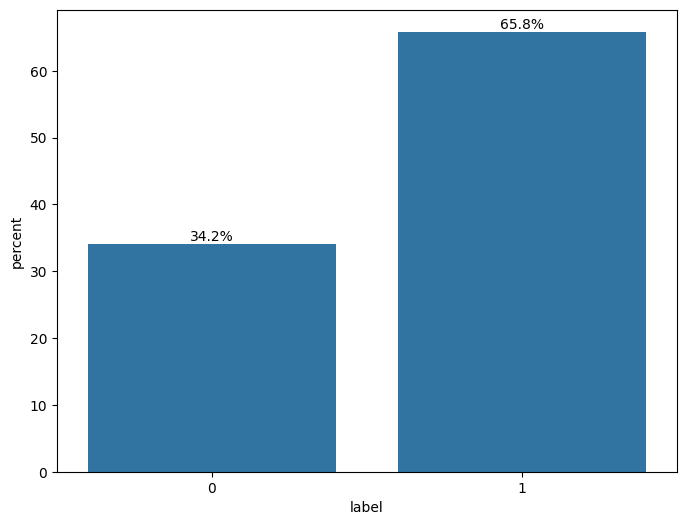

In [ ]:
plt.figure(figsize=(8,6))
ax = sns.countplot(x='label', data=data, stat="percent")

for p in ax.patches:
    percentage = '{:.1f}%'.format(p.get_height())
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')
plt.show()

Vemos que há mais reviews positivas do que negativas, mas não é uma diferença grande o suficiente para considerarmos tratá-la em um primeiro momento.

## Pré-processamento do texto

- Normalização para minúsculas;
- Filtrar apenas letras (removendo pontuações, símbolos, etc.);
- Remover stopwords;
- Lematizar.

Para remoção de `stopwords`, vamos usar a lista disponível na biblioteca `nltk`.

In [ ]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
stopwords_pt = stopwords.words("portuguese")

In [ ]:
stopwords_pt

['a',
 'à',
 'ao',
 'aos',
 'aquela',
 'aquelas',
 'aquele',
 'aqueles',
 'aquilo',
 'as',
 'às',
 'até',
 'com',
 'como',
 'da',
 'das',
 'de',
 'dela',
 'delas',
 'dele',
 'deles',
 'depois',
 'do',
 'dos',
 'e',
 'é',
 'ela',
 'elas',
 'ele',
 'eles',
 'em',
 'entre',
 'era',
 'eram',
 'éramos',
 'essa',
 'essas',
 'esse',
 'esses',
 'esta',
 'está',
 'estamos',
 'estão',
 'estar',
 'estas',
 'estava',
 'estavam',
 'estávamos',
 'este',
 'esteja',
 'estejam',
 'estejamos',
 'estes',
 'esteve',
 'estive',
 'estivemos',
 'estiver',
 'estivera',
 'estiveram',
 'estivéramos',
 'estiverem',
 'estivermos',
 'estivesse',
 'estivessem',
 'estivéssemos',
 'estou',
 'eu',
 'foi',
 'fomos',
 'for',
 'fora',
 'foram',
 'fôramos',
 'forem',
 'formos',
 'fosse',
 'fossem',
 'fôssemos',
 'fui',
 'há',
 'haja',
 'hajam',
 'hajamos',
 'hão',
 'havemos',
 'haver',
 'hei',
 'houve',
 'houvemos',
 'houver',
 'houvera',
 'houverá',
 'houveram',
 'houvéramos',
 'houverão',
 'houverei',
 'houverem',
 'hou

Nesta lista constam, por exemplo, as palvras `não` e `nem` que, se removidas do texto, podem mudar a interpretação do sentimento de uma frase. Vamos ajustar isso.

In [ ]:
stopwords_pt.remove('não')
stopwords_pt.remove('nem')

Vamos utilizar o lematizador da biblioteca Spacy. Para isso, precisamos fazer o download do modelo de português correspondente.

In [ ]:
import spacy.cli
spacy.cli.download("pt_core_news_sm")

✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Após o download, podemos importar o modelo.

In [ ]:
import pt_core_news_sm
spc_pt = pt_core_news_sm.load()

Agora estamos prontos para criar uma função que realiza os pré-processamentos e aplicá-la no dataset!

A funcão recebe uma string, deixa tudo em minúsculo, filtra apenas letras, retira *stopwords*, lemmatiza e retorna a string resultante.

In [ ]:
def limpa_texto(texto):
  texto = texto.lower()

  texto = re.sub(r"[\W\d_]+", " ", texto)

  texto = [pal for pal in texto.split() if pal not in stopwords_pt]

  spc_texto = spc_pt(" ".join(texto))
  tokens = [word.lemma_ if word.lemma_ != "-PRON-" else word.lower_ for word in spc_texto]

  return " ".join(tokens)

In [ ]:
# Demora aprox. 4 minutos!

data['review'] = data['review'].apply(limpa_texto)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 42389 entries, 3 to 99223
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   review_id               42389 non-null  object
 1   review_score            42389 non-null  int64 
 2   review_comment_title    42389 non-null  object
 3   review_comment_message  42389 non-null  object
 4   review                  42389 non-null  object
 5   label                   42389 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 2.3+ MB


In [ ]:
data.head(10)

,review_id,review_score,review_comment_title,review_comment_message,review,label
3,e64fb393e7b32834bb789ff8bb30750e,5,,Recebi bem antes do prazo estipulado.,recebi bem antes prazo estipular,1
4,f7c4243c7fe1938f181bec41a392bdeb,5,,Parabéns lojas lannister adorei comprar pela I...,parabéns loja lannister adorar comprar Interne...,1
9,8670d52e15e00043ae7de4c01cc2fe06,4,recomendo,aparelho eficiente. no site a marca do aparelh...,recomendar aparelho eficiente site marca apare...,1
12,4b49719c8a200003f700d3d986ea1a19,4,,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",pouco travar valor ta bom,1
15,3948b09f7c818e2d86c9a546758b2335,5,Super recomendo,"Vendedor confiável, produto ok e entrega antes...",super recomendo vendedor confiável produto ok ...,1
16,9314d6f9799f5bfba510cc7bcd468c01,2,,"GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E...",gostar saber sempre recebi compra agora decpci...,0
19,373cbeecea8286a2b66c97b1b157ec46,1,Não chegou meu produto,Péssimo,não chegar produto péssimo,0
22,d21bbc789670eab777d27372ab9094cc,5,Ótimo,Loja nota 10,bom loja noto,1
24,0e0190b9db53b689b285d3f3916f8441,5,,obrigado pela atençao amim dispensada,obrigar atençao amim dispensar,1
27,fe3db7c069d694bab50cc43463f91608,5,,A compra foi realizada facilmente.\r\nA entreg...,compra realizar facilmente entregar efetuar an...,1


In [ ]:
data[data['review'] == '']

,review_id,review_score,review_comment_title,review_comment_message,review,label
297,2b4a570df87cd63b232272dd9dcac0cf,5,,A,,1
463,3140a4eb146655fe104d54d385f9e9a0,5,,10,,1
583,3814f35a6ebd64d27e2130f30ec05255,4,5,,,1
598,057c9a1e8e767d8bf6fa59ac43a82435,4,4,,,1
939,8f965d010b3119d9962e091de3425fb9,4,,*******************,,1
...,...,...,...,...,...,...
94778,014f70270fa59804f14eb3df2ca690d2,5,,........................,,1
96770,47850e2adbd18f61f2af4af9b7656198,5,,👍🏻👌🏻👏🏻,,1
97441,e47fd0401fce7a7b6283da2a5a8ba563,5,10,,,1
98032,f004d8b3a2ff22e3c030285842cf629a,5,*****,,,1


Como temos análise com apenas números ou símbolos, ainda há dados faltantes na coluna `review`, vamos removê-los.

In [ ]:
data = data[data['review'] != '']

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 42129 entries, 3 to 99223
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   review_id               42129 non-null  object
 1   review_score            42129 non-null  int64 
 2   review_comment_title    42129 non-null  object
 3   review_comment_message  42129 non-null  object
 4   review                  42129 non-null  object
 5   label                   42129 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 2.2+ MB


In [ ]:
# Execute essa celula se quiser salvar o dataset pre-processado
data.to_csv('olist_preprocessado.csv', index= False, columns= ['review_id', 'review', 'label'])

Obs: poderíamos ter usado a biblioteca Spacy para tirar as *stopwords*, o que faria mais sentido já que iríamos usar o lematizador dela depois de qualquer forma.

No entanto, nesse caso, usar a lista da nltk deu melhores resultados.
Um possível motivo é que a lista de *stopwords* da Spacy é maior e pode ter tirado palavras importantes para a análise de sentimentos.

## *Feature extraction*


Essa etapa consiste em transformar o texto em informação numérica, mais precisamente um vetor, para que seja possível utilizá-lo para alimentar um modelo.

Vamos usar a biblioteca Scikit-Learn para realizar as duas técnicas de *feature extraction* que já vimos em aula, `Bag of Words` e `TF-IDF`.

### *Bag of Words*

Como vimos, essa representa o texto como um vetor onde cada elemento corresponde a uma palavra do vocabulário e seu valor é a quantidade de vezes que tal palavra aparece nesse texto, ou então simplesmente 0 se a palavra não aparece nele e 1 se aparece.

A função `CountVectorizer` do Scikit-Learn foi criada para fazer isso!

O parâmetro `binary` indica se será usada a contagem total das palavras ou apenas 0s e 1s.

Já o parâmetro `max_features` define o tamanho do vocabulário, assim `max_features=5000` constrói o vocabulário com as 5.000 palavras que mais ocorrem nos textos.

In [ ]:
# Importando o CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
# Instanciando o CountVectorizer, binary=True faz a codificacao binaria
vectorizer = CountVectorizer(binary=True, max_features=5000)

texto = data['review']

# Vetorizando o texto
X_bow = vectorizer.fit_transform(texto)

### TF-IDF

Já essa técnica vetoriza o texto atribuindo para cada palavra uma pontuação que mede a importância dela no texto.

Também temos uma função no Scikit-Learn que já faz isso, a `TfidfVectorizer`

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
# Instanciando o TfidfVectorizer
tfidf_vect = TfidfVectorizer(max_features=5000)

# Vetorizando
X_tfidf = tfidf_vect.fit_transform(texto)

# Modelos

Dividindo os dados em base de treino e teste (70-30).

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# Texto processado com BoW
X1_train, X1_test, y1_train, y1_test = train_test_split(X_bow, data['label'],
                                                        test_size=0.3, random_state = 10)

# Texto processado com TF-IDF
X2_train, X2_test, y2_train, y2_test = train_test_split(X_tfidf, data['label'],
                                                        test_size=0.3, random_state = 10)

Importando as métricas que serão usadas para avaliação de cada modelo.

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_auc_score, ConfusionMatrixDisplay

In [ ]:
def mostra_metricas(y_true, y_pred):
  print("Acurácia: ", accuracy_score(y_true, y_pred))
  print("\nF1-Score:", f1_score(y_true, y_pred, average='weighted'))
  print("\nMatriz de confusão:")
  cm = confusion_matrix(y_true, y_pred)
  cm_disp = ConfusionMatrixDisplay(confusion_matrix=cm)
  cm_disp.plot()
  plt.show()

## Regressão Logística

Vamos ver como a regressão logística lida com o problema de análise de sentimentos.

### Texto vetorizado com *Bag of Words*.

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
# Instanciando a reg. logistica
reglog = LogisticRegression()

# Aplicando o modelo
reglog.fit(X1_train, y1_train)

LogisticRegression()

In [ ]:
# Predicao
y1_reglog_pred = reglog.predict(X1_test)

Analisando as métricas.

Acurácia:  0.8920800696257616

F1-Score: 0.8915220165974829

Matriz de confusão:


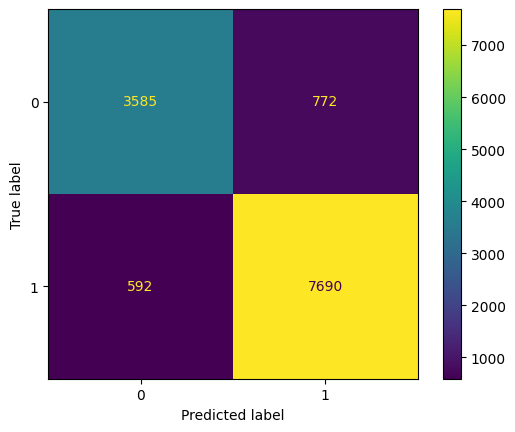

In [ ]:
mostra_metricas(y1_test, y1_reglog_pred)

### Texto vetorizado com tf-idf.

In [ ]:
reglog2 = LogisticRegression()

reglog2.fit(X2_train, y2_train)

y2_reglog_pred = reglog2.predict(X2_test)

Acurácia:  0.8947701558667616

F1-Score: 0.8946189553766845

Matriz de confusão:


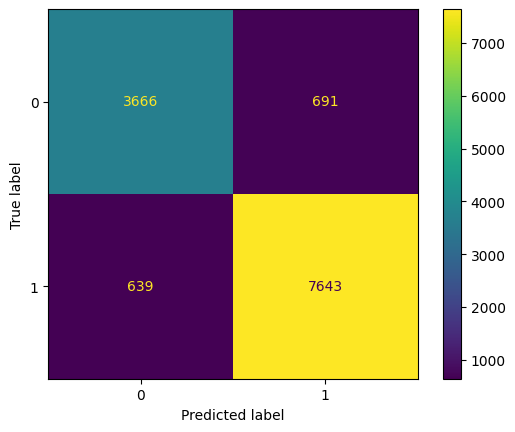

In [ ]:
mostra_metricas(y2_test, y2_reglog_pred)

A diferença do desempenho do modelo com os 2 métodos de *feature extraction* foi pequena, neste caso, mas as métricas apontam a melhor foi a `tf-idf`.

## Resultados

Para terminar, vamos avaliar como o modelo atua em novos textos, simulando novas avaliações a partir do modelo que performou melhor, o `tf-idf`.

In [ ]:
def nova_predicao(texto):
  '''Funcao que recebe uma string e apresenta a predicao feita
  pelo modelo.'''
  texto_vetorizado = tfidf_vect.transform([texto])
  pred = reglog2.predict(texto_vetorizado)

  if pred == 0:
    print("Essa é uma review negativa.")
  else:
    print("Essa é uma review positiva.")

In [ ]:
nova_predicao("Demorou muito não gostei")

Essa é uma review negativa.


In [ ]:
nova_predicao("Achei cheirosinho")

Essa é uma review positiva.


In [ ]:
nova_predicao("Nossa que produto ruim é esse parece que encontrei no lixo")

Essa é uma review negativa.


In [ ]:
nova_predicao("Gostei")

Essa é uma review positiva.


In [ ]:
nova_predicao("Não gostei")

Essa é uma review negativa.


In [ ]:
nova_predicao("Que produtinho, hein")

Essa é uma review positiva.


In [ ]:
nova_predicao("apesar do atendimento péssimo, gostei muito do produto!")

Essa é uma review negativa.


In [ ]:
nova_predicao("apesar do atendimento ruim, gostei muito do produto!")

Essa é uma review negativa.


In [ ]:
nova_predicao("apesar do atendimento mediano, gostei muito do produto!")

Essa é uma review positiva.


## **TAREFA**

Tente melhorar a performance do modelo usando um novo algoritmo que bata a Regressão Logística!

Entregue o Colab com seus resultados até o dia 25/05, compartilhando-o com o professor (cassius.figueiredo@professores.ibmec.edu.br).

## Analise dos resultados dos modelos

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import time

# ----------------------------------------------------------
# 1. BASELINE – Regressão Logística (TF-IDF, já treinada)
# ----------------------------------------------------------
baseline_acc = accuracy_score(y2_test, y2_reglog_pred)
baseline_f1  = f1_score(y2_test, y2_reglog_pred, average="weighted")

print("=" * 60)
print(f"BASELINE  →  Regressão Logística (TF-IDF)")
print(f"  Acurácia : {baseline_acc:.4f}")
print(f"  F1-Score : {baseline_f1:.4f}")
print("=" * 60)

# ----------------------------------------------------------
# 2. CANDIDATOS A TESTAR
# ----------------------------------------------------------
candidatos = [
    ("LinearSVC  C=0.01",    LinearSVC(C=0.01, max_iter=3000),       X2_train, X2_test, y2_train, y2_test),
    ("LinearSVC  C=0.05",    LinearSVC(C=0.05, max_iter=3000),       X2_train, X2_test, y2_train, y2_test),
    ("LinearSVC  C=0.1",     LinearSVC(C=0.1,  max_iter=3000),       X2_train, X2_test, y2_train, y2_test),
    ("LinearSVC  C=0.5",     LinearSVC(C=0.5,  max_iter=3000),       X2_train, X2_test, y2_train, y2_test),
    ("RegLog     C=0.1",     LogisticRegression(C=0.1,  max_iter=500), X2_train, X2_test, y2_train, y2_test),
    ("RegLog     C=5.0",     LogisticRegression(C=5.0,  max_iter=500), X2_train, X2_test, y2_train, y2_test),
    ("RegLog     C=10.0",    LogisticRegression(C=10.0, max_iter=500), X2_train, X2_test, y2_train, y2_test),
    ("NB Multinomial a=0.1", MultinomialNB(alpha=0.1),               X2_train, X2_test, y2_train, y2_test),
    ("NB Complement  a=0.1", ComplementNB(alpha=0.1),                X2_train, X2_test, y2_train, y2_test),
]

# ----------------------------------------------------------
# 3. TREINO, PREDIÇÃO E COLETA DE MÉTRICAS
# ----------------------------------------------------------
resultados = []

resultados.append({
    "Modelo"        : "Regressão Logística (TF-IDF) ← baseline",
    "Acurácia"      : round(baseline_acc, 4),
    "F1 Ponderado"  : round(baseline_f1,  4),
    "Tempo (s)"     : "—",
    "Bate Baseline?": "—",
})

for nome, modelo, Xtr, Xte, ytr, yte in candidatos:
    inicio = time.time()
    modelo.fit(Xtr, ytr)
    y_pred = modelo.predict(Xte)
    elapsed = round(time.time() - inicio, 2)

    acc = accuracy_score(yte, y_pred)
    f1  = f1_score(yte, y_pred, average="weighted")
    bate = "✅  SIM" if acc > baseline_acc else "❌  NÃO"  # comparação por acurácia

    resultados.append({
        "Modelo"        : nome,
        "Acurácia"      : round(acc, 4),
        "F1 Ponderado"  : round(f1,  4),
        "Tempo (s)"     : elapsed,
        "Bate Baseline?": bate,
    })

# ----------------------------------------------------------
# 4. RANKING (ordenado por Acurácia)
# ----------------------------------------------------------
df_rank = pd.DataFrame(resultados)
df_rank = df_rank.sort_values("Acurácia", ascending=False).reset_index(drop=True)
df_rank.index += 1

print("\n📊  RANKING DOS MODELOS (ordenado por Acurácia)\n")
print(df_rank.to_string())

# ----------------------------------------------------------
# 5. MELHOR MODELO
# ----------------------------------------------------------
melhor = df_rank.iloc[0]
print("\n" + "=" * 60)
print(f"🏆  MELHOR MODELO  →  {melhor['Modelo']}")
print(f"   Acurácia    : {melhor['Acurácia']}")
print(f"   F1-Score    : {melhor['F1 Ponderado']}")
print("=" * 60)

# ----------------------------------------------------------
# 6. CONCLUSÃO
# ----------------------------------------------------------
vencedores = df_rank[
    (df_rank["Bate Baseline?"] == "✅  SIM") &
    (df_rank["Modelo"] != "Regressão Logística (TF-IDF) ← baseline")
]

if not vencedores.empty:
    print(f"\n✅  {len(vencedores)} modelo(s) superaram a Regressão Logística:")
    for _, row in vencedores.iterrows():
        print(f"   • {row['Modelo']}  (Acurácia = {row['Acurácia']})")
else:
    print("\n⚠️  Nenhum modelo superou o baseline nesta configuração.")

BASELINE  →  Regressão Logística (TF-IDF)
  Acurácia : 0.8948
  F1-Score : 0.8946

📊  RANKING DOS MODELOS (ordenado por Acurácia)

                                     Modelo  Acurácia  F1 Ponderado Tempo (s) Bate Baseline?
1                          LinearSVC  C=0.1    0.8956        0.8955      0.06         ✅  SIM
2   Regressão Logística (TF-IDF) ← baseline    0.8948        0.8946         —              —
3                          RegLog     C=5.0    0.8948        0.8946      0.44         ❌  NÃO
4                         LinearSVC  C=0.05    0.8946        0.8945      0.05         ❌  NÃO
5                          LinearSVC  C=0.5    0.8935        0.8934      0.13         ❌  NÃO
6                         RegLog     C=10.0    0.8914        0.8912      0.57         ❌  NÃO
7                          RegLog     C=0.1    0.8875        0.8867      0.24         ❌  NÃO
8                      NB Multinomial a=0.1    0.8869        0.8875      0.01         ❌  NÃO
9                         Linear

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import time

# ----------------------------------------------------------
# 1. BASELINE – melhor modelo encontrado
# ----------------------------------------------------------
baseline_acc = 0.8956  # LinearSVC C=0.1
baseline_f1  = 0.8955

print("=" * 60)
print(f"BASELINE  →  LinearSVC C=0.1 (melhor anterior)")
print(f"  Acurácia : {baseline_acc:.4f}")
print(f"  F1-Score : {baseline_f1:.4f}")
print("=" * 60)

# ----------------------------------------------------------
# 2. SWEEP FINO em torno de C=0.1
# ----------------------------------------------------------
candidatos = [
    (f"LinearSVC  C={c}", LinearSVC(C=c, max_iter=3000), X2_train, X2_test, y2_train, y2_test)
    for c in [0.07, 0.08, 0.09, 0.10, 0.11, 0.12, 0.13, 0.15, 0.2, 0.3]
]

# ----------------------------------------------------------
# 3. TREINO, PREDIÇÃO E COLETA DE MÉTRICAS
# ----------------------------------------------------------
resultados = []

resultados.append({
    "Modelo"        : "LinearSVC C=0.1 ← baseline",
    "Acurácia"      : baseline_acc,
    "F1 Ponderado"  : baseline_f1,
    "Tempo (s)"     : "—",
    "Bate Baseline?": "—",
})

for nome, modelo, Xtr, Xte, ytr, yte in candidatos:
    inicio = time.time()
    modelo.fit(Xtr, ytr)
    y_pred = modelo.predict(Xte)
    elapsed = round(time.time() - inicio, 2)

    acc = accuracy_score(yte, y_pred)
    f1  = f1_score(yte, y_pred, average="weighted")
    bate = "✅  SIM" if acc > baseline_acc else "❌  NÃO"

    resultados.append({
        "Modelo"        : nome,
        "Acurácia"      : round(acc, 4),
        "F1 Ponderado"  : round(f1,  4),
        "Tempo (s)"     : elapsed,
        "Bate Baseline?": bate,
    })

# ----------------------------------------------------------
# 4. RANKING
# ----------------------------------------------------------
df_rank = pd.DataFrame(resultados)
df_rank = df_rank.sort_values("Acurácia", ascending=False).reset_index(drop=True)
df_rank.index += 1

print("\n📊  RANKING DOS MODELOS (ordenado por Acurácia)\n")
print(df_rank.to_string())

melhor = df_rank.iloc[0]
print("\n" + "=" * 60)
print(f"🏆  MELHOR MODELO  →  {melhor['Modelo']}")
print(f"   Acurácia    : {melhor['Acurácia']}")
print(f"   F1-Score    : {melhor['F1 Ponderado']}")
print("=" * 60)

vencedores = df_rank[
    (df_rank["Bate Baseline?"] == "✅  SIM") &
    (df_rank["Modelo"] != "LinearSVC C=0.1 ← baseline")
]

if not vencedores.empty:
    print(f"\n✅  {len(vencedores)} modelo(s) superaram o baseline:")
    for _, row in vencedores.iterrows():
        print(f"   • {row['Modelo']}  (Acurácia = {row['Acurácia']})")
else:
    print("\n⚠️  C=0.1 já é o ponto ótimo nessa faixa.")

BASELINE  →  LinearSVC C=0.1 (melhor anterior)
  Acurácia : 0.8956
  F1-Score : 0.8955

📊  RANKING DOS MODELOS (ordenado por Acurácia)

                        Modelo  Acurácia  F1 Ponderado Tempo (s) Bate Baseline?
1            LinearSVC  C=0.12    0.8960        0.8960      0.14         ✅  SIM
2            LinearSVC  C=0.13    0.8960        0.8959      0.07         ✅  SIM
3            LinearSVC  C=0.15    0.8959        0.8958      0.23         ✅  SIM
4             LinearSVC  C=0.2    0.8956        0.8955      0.08         ✅  SIM
5            LinearSVC  C=0.11    0.8956        0.8955      0.16         ❌  NÃO
6   LinearSVC C=0.1 ← baseline    0.8956        0.8955         —              —
7             LinearSVC  C=0.1    0.8956        0.8955      0.18         ❌  NÃO
8            LinearSVC  C=0.09    0.8954        0.8953       0.1         ❌  NÃO
9            LinearSVC  C=0.08    0.8953        0.8953      0.08         ❌  NÃO
10            LinearSVC  C=0.3    0.8952        0.8951       0.1